# Lab 06 Hints: New Python Tools
*Elements of Data Science — Honors*

Lab 06 introduces several Python tools you haven't used yet. This notebook teaches each one on a **small, different example** — a 6-sided die instead of a 20-sided die, a made-up DNA string, a pantry dictionary. Run each cell, see how the tool behaves, then carry the pattern back to the lab yourself.

**How to use it**
- Work through the section that matches the part of the lab you're on.
- When a cell says **Predict**, decide what you expect *before* you run it. Being wrong is useful: it tells you exactly what you didn't understand.
- Nothing here is graded, and nothing here is the answer to a lab question.

| Section | New idea | Helps with |
|---|---|---|
| 1 | Simulating with a function; histograms of whole-number outcomes | Q1.1 – Q1.4 |
| 2 | Estimating an unknown number from data | Q1.5 – Q1.7 |
| 3 | Sampling from a population with `Table.sample()` | Q1.8, Q1.9 |
| 4 | Strings as sequences: indexing, slicing, `.count()`, sliding windows | Q2.1A, Q2.1B |
| 5 | Python lists and `.append()`; `range()` | Q2.1B – Q2.3 |
| 6 | **Dictionaries** | Q3.1, Q3.2, RSV article |
| 7 | Filtering text: `.isalpha()`, `in`, list comprehensions with `if`, reading files | RSV article |
| 8 | Decoding error messages | everywhere |

In [1]:
import numpy as np
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

---
## 1. Simulating a roll and storing the result

You've used `np.random.choice` before (Lab 5). The new part in Lab 06 is **keeping several results in names** — the roll, the total, and whether it succeeded — so later lines can use them.

A board game: roll a 6-sided die, add a bonus of 2, and you succeed if the total is **greater than 5**.

In [2]:
d6 = np.arange(1, 7)          # the six faces: 1, 2, 3, 4, 5, 6
roll = np.random.choice(d6)   # one random face
total = roll + 2
made_it = total > 5           # a comparison gives True or False
print(roll, total, made_it)

2 4 False


`made_it` holds a **boolean** (`True`/`False`). A comparison produces a value just like arithmetic does, so you can give it a name.

Run the cell above several times. Out of, say, 6 runs, how many succeeded? That fraction is a rough estimate of the chance of success. (Exact answer: totals 6, 7, 8 succeed, which is faces 4, 5, 6 → 3 out of 6.)

### Reading an f-string
The lab's print line uses an **f-string**: a string with `f` in front, where anything inside `{ }` is replaced by its value.

In [ ]:
print(f"Rolled a {roll}, so the total is {total}.")

The lab also puts a tiny *if/else* inside the braces: `'succeeded' if action_succeeded else 'failed'` picks one of two strings. These two cells do the same thing:

In [3]:
# Short form (one line)
word = 'made it' if made_it else 'missed'
print(f"With a total of {total}, the player {word}.")

With a total of 4, the player missed.


In [4]:
# Long form (the if/else you know from Lab 5)
if made_it:
    word = 'made it'
else:
    word = 'missed'
print(f"With a total of {total}, the player {word}.")

With a total of 4, the player missed.


### A function that returns many simulated results
Two ways to get several rolls. Both return an **array**.

**Way 1 — a loop** (the Lab 5 pattern). Start with 10 repetitions so you can inspect the output.

In [5]:
def roll_d6_plus_loop(bonus, how_many):
    '''Return an array of how_many simulated totals (d6 roll + bonus).'''
    totals = make_array()
    for i in np.arange(how_many):
        one_total = np.random.choice(np.arange(1, 7)) + bonus
        totals = np.append(totals, one_total)
    return totals

roll_d6_plus_loop(2, 10)

array([ 3.,  3.,  5.,  7.,  8.,  3.,  7.,  4.,  7.,  8.])

(The totals print with a decimal point, like `7.`, because an empty `make_array()` starts out holding decimals. The values are the same.)

**Way 2 — ask `np.random.choice` for many at once**, then add the bonus to the whole array (array arithmetic, Lab 2).

In [6]:
def roll_d6_plus(bonus, how_many):
    '''Return an array of how_many simulated totals (d6 roll + bonus).'''
    rolls = np.random.choice(np.arange(1, 7), how_many)
    totals = rolls + bonus
    return totals

roll_d6_plus(2, 10)

array([4, 6, 4, 8, 3, 7, 3, 3, 5, 8])

**Check yourself:** with a bonus of 2, what is the smallest total that can ever appear? The largest? Look at the output — does it agree?

> **Side note on `np.random.randint`.** The lab uses `np.random.randint(1, 21)`. Like `np.arange`, the stop value is **excluded**, so this gives a whole number from 1 to 20. `np.random.randint(1, 7)` is one roll of a d6.

### Histograms of whole-number outcomes: choose the bins
**Predict:** if you roll 10 times, will every total from 3 to 8 show up at least once?

In [7]:
totals_10 = roll_d6_plus(2, 10)
totals_10

array([4, 6, 8, 6, 7, 5, 8, 3, 5, 3])

Now plot it with `plt.hist`'s default bins. The default splits the range into 10 equal slices, which doesn't line up with whole numbers — some bars sit between values and some slices are always empty.

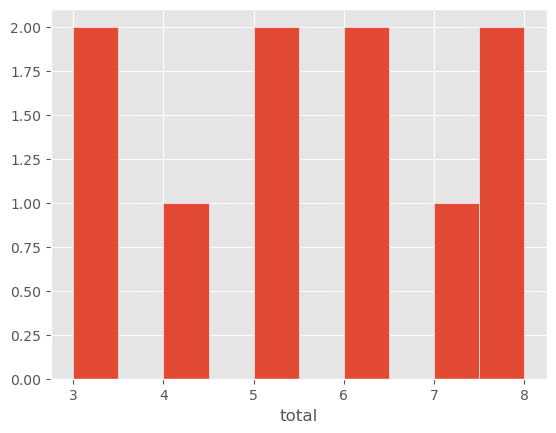

In [8]:
plt.hist(totals_10)
plt.xlabel('total');

Give it **one bin per possible value**. Bin edges `3, 4, 5, …, 9` make bins `[3,4)`, `[4,5)`, …, `[8,9)`, so each bin holds exactly one whole number. Notice the last edge has to be **one more than the largest possible total**.

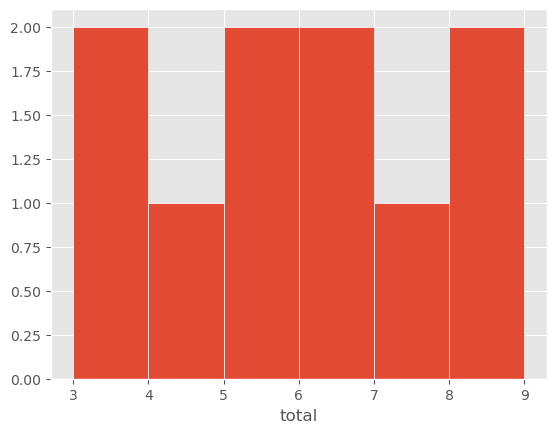

In [9]:
total_bins = np.arange(3, 10)   # edges 3, 4, ..., 9
plt.hist(totals_10, bins=total_bins, ec='white')
plt.xlabel('total');

### Probability distribution vs. what you observed
The **probability distribution** says how likely each outcome is in theory. For a fair die every total from 3 to 8 has chance 1/6. One way to draw it: put each possible outcome in **once** and use `density=True` so bar heights are proportions.

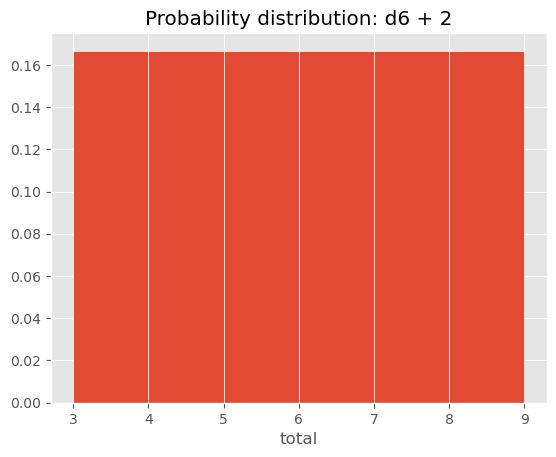

In [10]:
all_possible_totals = np.arange(1, 7) + 2
plt.hist(all_possible_totals, bins=total_bins, density=True, ec='white')
plt.title('Probability distribution: d6 + 2')
plt.xlabel('total');

The histogram of **simulated** rolls is an *empirical* distribution. **Predict:** as the number of rolls grows from 10 to 100 to 10,000, what happens to its shape? Run and compare with the flat probability histogram.

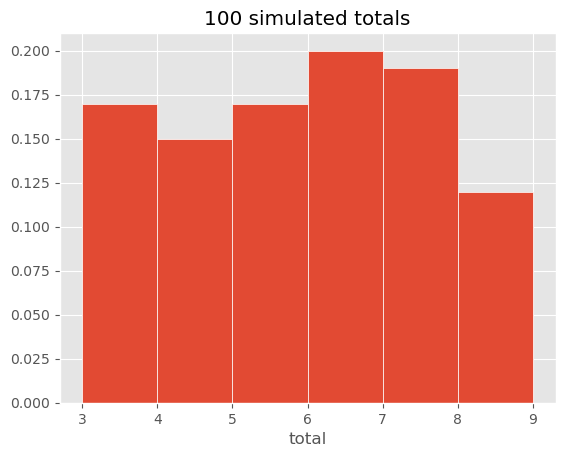

In [11]:
many_totals = roll_d6_plus(2, 100)     # try 10, then 100, then 10000
plt.hist(many_totals, bins=total_bins, density=True, ec='white')
plt.title(f'{len(many_totals)} simulated totals')
plt.xlabel('total');

---
## 2. Estimating a number you can't see

Now flip the problem around. A friend rolls a d6 and adds a **secret bonus**. You only see the totals. Can you work backwards to the bonus?

A rule that turns data into a guess is called an **estimator**. Lab 06 compares two of them.

In [12]:
secret_bonus = np.random.randint(0, 10)       # hidden from you -- don't print it yet!
seen = roll_d6_plus(secret_bonus, 7)          # 7 observed totals
seen

array([14, 13, 10, 10, 14,  9,  9])

### Estimator A: use the smallest total
The smallest face on a d6 is 1, so the smallest possible total is `bonus + 1`. If one of your 7 rolls happened to be a 1, then `min(seen) - 1` is exactly the bonus.

**Predict (commit before running the next cell):** can this estimate ever come out *smaller* than the true bonus? Can it come out *larger*?

In [13]:
def min_based(obs):
    return min(obs) - 1

min_based(seen)

8

### Estimator B: use the average
Think it through on paper first:
1. What is the average of the faces 1–6? (You can compute it exactly, or simulate thousands of rolls and average them.)
2. Adding a bonus to every roll adds the same bonus to the average.
3. So if you know the average of the totals, how do you get back to the bonus?

Write your answer as a one-line function, then compare with the cell after it.

In [14]:
print('Exact average of a d6:', np.mean(np.arange(1, 7)))
print('Average of 10,000 simulated d6 rolls:', np.mean(np.random.choice(np.arange(1, 7), 10000)))

Exact average of a d6: 3.5
Average of 10,000 simulated d6 rolls: 3.4713


In [15]:
def mean_based(obs):
    return np.mean(obs) - 3.5

mean_based(seen)

7.7857142857142865

Notice `mean_based` usually gives a **decimal**, even though the true bonus is a whole number. That's normal for an estimate. Now reveal the truth:

In [16]:
print('min-based estimate: ', min_based(seen))
print('mean-based estimate:', mean_based(seen))
print('true bonus:         ', secret_bonus)

min-based estimate:  8
mean-based estimate: 7.78571428571
true bonus:          8


### Going further: which estimator is better?
One experiment can't tell you. Repeat the whole experiment many times with a **known** bonus and record each estimator's error (estimate − truth). Start with 10 repetitions, look at the arrays, then change 10 to 1000.

In [17]:
true_bonus = 4
min_errors = make_array()
mean_errors = make_array()
for i in np.arange(10):
    obs = roll_d6_plus(true_bonus, 7)
    min_errors = np.append(min_errors, min_based(obs) - true_bonus)
    mean_errors = np.append(mean_errors, mean_based(obs) - true_bonus)

print('min-based errors: ', min_errors)
print('mean-based errors:', mean_errors)

min-based errors:  [ 0.  0.  0.  0.  0.  0.  0.  2.  0.  0.]
mean-based errors: [ 0.35714286 -0.78571429 -0.07142857 -0.07142857  0.07142857 -0.21428571
  0.07142857  0.78571429 -0.78571429 -0.5       ]


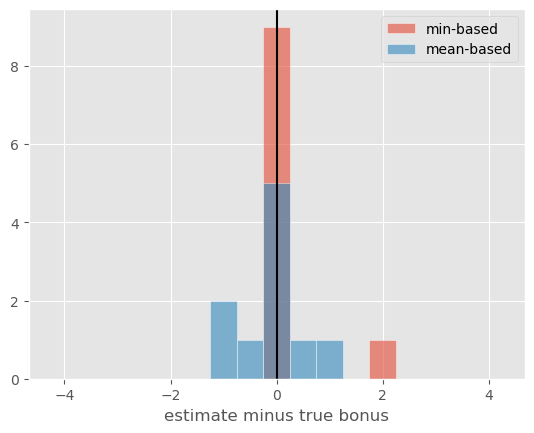

In [18]:
error_bins = np.arange(-4.25, 4.3, 0.5)   # bins centered on -4, -3.5, ..., 4
plt.hist(min_errors, bins=error_bins, alpha=0.6, label='min-based', ec='white')
plt.hist(mean_errors, bins=error_bins, alpha=0.6, label='mean-based', ec='white')
plt.axvline(0, color='black')
plt.xlabel('estimate minus true bonus')
plt.legend();

**Questions to think about**
- Does the min-based error ever go below 0? Why not?
- Which estimator is exactly right more often? Which one is centered on the truth?
- With a d6 and 7 rolls, the chance that at least one roll is a 1 is 1 − (5/6)<sup>7</sup> ≈ 72%. For a **d20** and 7 rolls, the chance at least one roll is a 1 is 1 − (19/20)<sup>7</sup> ≈ 30%. What does that predict about the min-based estimator in the lab?

---
## 3. Sampling from a population with `Table.sample()`

**Simulating** makes brand-new data from a model (`np.random.choice` rolling a die). **Sampling** draws a smaller group out of data that **already exists** — the *population*. Tables have a built-in method for this: `.sample()`.

To see exactly what `.sample()` does, use a population small enough to check by hand: the whole numbers 1 through 100. Its mean is exactly 50.5.

In [19]:
population = Table().with_columns('value', np.arange(1, 101))
print('rows:', population.num_rows, '  population mean:', np.mean(population.column('value')))

rows: 100   population mean: 50.5


### With or without replacement?
`some_table.sample(k)` returns a **new Table** with `k` randomly chosen rows. The important detail is the `with_replacement` option:

- `with_replacement=True` — after a row is picked it goes back in, so it **can be picked again**. This is the **default** if you don't say anything.
- `with_replacement=False` — each row can be picked **at most once**, like drawing names out of a hat.

Use a 5-row table to see the difference. **Predict:** if you sample 5 rows *without* replacement from a 5-row table, what do you get back? What about *with* replacement? Run each cell a few times.

In [20]:
tiny = Table().with_columns('name', make_array('Ana', 'Ben', 'Cal', 'Dee', 'Eli'))
tiny.sample(5, with_replacement=False)

name
Ana
Cal
Dee
Ben
Eli


In [21]:
tiny.sample(5)      # default: with_replacement=True

name
Dee
Eli
Ben
Cal
Ben


Without replacement you always get all five names back, just shuffled. With replacement some names repeat and others go missing. When a question says **without replacement**, you have to type `with_replacement=False` yourself.

### A sample mean is an estimate
Pull a sample, then take the mean of one of its columns, just as you would for any Table:

In [22]:
sample_10 = population.sample(10, with_replacement=False)
sample_10_mean = np.mean(sample_10.column('value'))
sample_10_mean

45.899999999999999

**Predict:** if you re-run the cell above, will you get the same mean? Will it be exactly 50.5?

### How does sample size matter?
The loop below draws samples of three sizes. `{value:.2f}` inside an f-string means *show this number rounded to 2 decimal places*. Run it several times and watch which means wiggle the most.

In [23]:
for k in make_array(5, 20, 80):
    s = population.sample(k, with_replacement=False)
    print(f"n = {k}: sample mean = {np.mean(s.column('value')):.2f}   (population mean = 50.50)")

n = 5: sample mean = 58.20   (population mean = 50.50)
n = 20: sample mean = 35.65   (population mean = 50.50)
n = 80: sample mean = 51.86   (population mean = 50.50)


Something to try: what happens if you sample **all 100** rows without replacement? Why is the sample mean then always exactly 50.5?

### Making a population Table from a list
The lab builds a population with a list comprehension, `[len(word) for word in darwin_words]` — one number per word. Here is the same pattern on a short list of words:

In [24]:
some_words = ['sampling', 'is', 'not', 'simulation']
lengths = [len(word) for word in some_words]
print(lengths)
Table().with_columns('word_length', lengths)

[8, 2, 3, 10]


word_length
8
2
3
10


---
## 4. Strings are sequences

A string is an ordered sequence of characters, so you can pull out pieces of it by **position**, just like elements of an array. Positions start at **0**.

```
 position:  0  1  2  3  4  5  6  7  8  9
 dna:       G  A  T  T  A  C  A  G  G  C
```

In [25]:
dna = "GATTACAGGC"
print(len(dna))
print(dna[0])     # first character
print(dna[4])     # fifth character

10
G
A


### Slicing: `text[start:stop]`
A **slice** gives the characters from `start` up to **but not including** `stop` — the same rule as `np.arange`. So `dna[0:4]` has 4 characters: positions 0, 1, 2, 3.

**Predict:** what is `dna[2:5]`? What is `dna[7:10]`?

In [26]:
print(dna[0:4])
print(dna[2:5])
print(dna[7:10])

GATT
TTA
GGC


### Counting characters with `.count()`
`.count('A')` returns how many times `'A'` appears. It works on a whole string or on a slice.

In [27]:
print(dna.count('A'))
print(dna[0:4].count('A'))

3
1


To get a **fraction** of the letters in a piece, count what you want and divide by the length of the piece. Example: the fraction of the first 4 letters that are T:

In [28]:
t_count = dna[0:4].count('T')
t_fraction = t_count / 4
t_fraction

0.5

### Looping over the characters of a string
A `for` loop steps through a string one character at a time, just as it steps through an array.

In [29]:
for letter in "GATTACA":
    print(letter.lower())

g
a
t
t
a
c
a


### Sliding windows
To look at *every* stretch of 3 letters, let the loop variable `i` be the **start** of the slice and use `dna[i:i+3]`. Each time through, the window slides one letter to the right.

In [30]:
window = 3
for i in np.arange(5):
    print(i, dna[i:i+window])

0 GAT
1 ATT
2 TTA
3 TAC
4 ACA


**Predict:** `dna` has 10 letters. How many different 3-letter windows fit? (The last window must end at the last letter.) Then check:

In [31]:
window = 3
for i in range(len(dna) - window + 1):
    print(i, dna[i:i+window])

0 GAT
1 ATT
2 TTA
3 TAC
4 ACA
5 CAG
6 AGG
7 GGC


> In Q2.1B the lab gives you the loop line `for i in range(len(seq)-samplesize):` — keep it exactly as given. Worth a thought, though: compared with the cell above, which window does it visit, and which does it skip?

### Always check your data before computing fractions
A stray space or line break inside a sequence gets counted in `len()` but isn't a nucleotide. Here's a quick check: do the four letters account for every character?

In [32]:
messy = "GATTA CAGGC"
letters = messy.count('A') + messy.count('C') + messy.count('G') + messy.count('T')
print('length:', len(messy), '  A+C+G+T:', letters, '  spaces:', messy.count(' '))

length: 11   A+C+G+T: 10   spaces: 1


Try the same check on the lab's `seq`. If the numbers don't match, think about what that does to a window's GC fraction.

---
## 5. Python lists and `.append()`

Lab 06 collects results in a **Python list** instead of an array. You made lists in Lab 3 with square brackets. New here: an **empty** list `[]` that grows with `.append()`.

In [33]:
fractions = []
fractions.append(0.5)
fractions.append(0.25)
fractions

[0.5, 0.25]

### The one big difference from `np.append`

| | array | list |
|---|---|---|
| start empty | `results = make_array()` | `results = []` |
| add one value | `results = np.append(results, x)` | `results.append(x)` |
| what happens | makes a **new** array; you must reassign it | **changes the list in place**; no `=` |

Because `.append()` changes the list in place, it hands back nothing (`None`). So **don't** write `results = results.append(x)`. **Predict** what this prints:

In [34]:
oops = []
oops = oops.append(1)
print(oops)

None


### Filling a list in a loop
Same loop pattern as Lab 5, with a list. Ten coin flips:

In [35]:
flips = []
for i in np.arange(10):
    flips.append(np.random.choice(['H', 'T']))
flips

['H', 'T', 'H', 'T', 'H', 'H', 'H', 'H', 'H', 'H']

### `range()` vs. `np.arange()`
The lab uses both. For counting through positions in a loop they behave the same way: start at 0 and stop **before** the number you give.

In [36]:
print(list(range(5)))
print(np.arange(5))

[0, 1, 2, 3, 4]
[0 1 2 3 4]


### A function that returns a list: sliding windows over coin flips
This combines Sections 4 and 5: slide a window along a string of flips and record the **fraction of heads** in each window. Test it on a short string you can check by hand first.

**Predict:** for `"HHTHTTTHHH"` with windows of 3, what is the first fraction? The last?

In [37]:
def heads_fraction_windows(flip_string, size):
    fractions = []
    for i in range(len(flip_string) - size + 1):
        piece = flip_string[i:i+size]
        fractions.append(piece.count('H') / size)
    return fractions

heads_fraction_windows("HHTHTTTHHH", 3)

[0.6666666666666666,
 0.6666666666666666,
 0.3333333333333333,
 0.3333333333333333,
 0.0,
 0.3333333333333333,
 0.6666666666666666,
 1.0]

Lists work with the summary functions you already know, and `plt.plot` draws the values in order:

max: 1.0  min: 0.0
mean: 0.5  median: 0.5


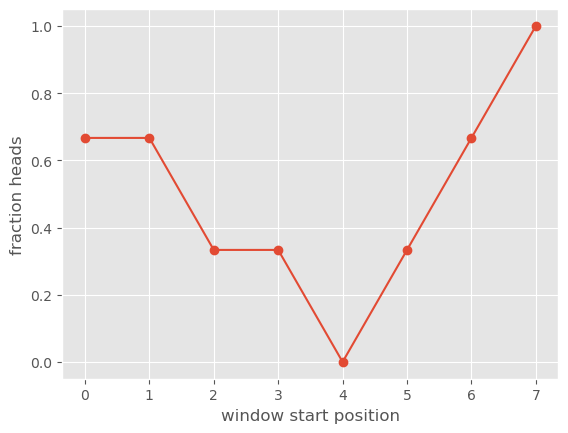

In [38]:
results = heads_fraction_windows("HHTHTTTHHH", 3)
print('max:', max(results), ' min:', min(results))
print('mean:', np.mean(results), ' median:', np.median(results))
plt.plot(results, marker='o')
plt.xlabel('window start position')
plt.ylabel('fraction heads');

### How does window size change the picture?
Below: 300 random flips, analyzed with a small window and a large one. **Predict** which plot will look jumpier before you run it. (Slicing and `.count()` also work on lists, so we can keep the flips as a list.)

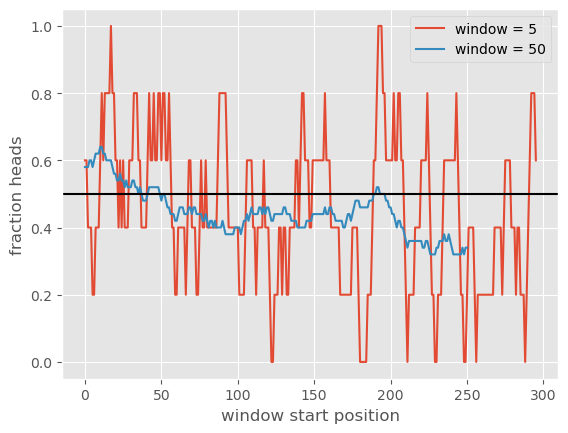

In [39]:
long_flips = []
for i in np.arange(300):
    long_flips.append(np.random.choice(['H', 'T']))

plt.plot(heads_fraction_windows(long_flips, 5), label='window = 5')
plt.plot(heads_fraction_windows(long_flips, 50), label='window = 50')
plt.axhline(0.5, color='black')
plt.xlabel('window start position')
plt.ylabel('fraction heads')
plt.legend();

These flips are purely random, so any "high" or "low" stretch is chance. Keep that in mind when you look for GC-rich regions in the lab: how would you tell a real GC-rich stretch from a chance bump?

---
## 6. Dictionaries

A **dictionary** stores **pairs**: a *key* and its *value*. You look things up by key, the way you look up a word in a real dictionary to find its definition.

Compare a list of numbers (which number is which?) with a dictionary (each number has a label):

In [40]:
pantry_list = [4, 12, 1]
pantry = {'apples': 4, 'eggs': 12, 'milk': 1}
pantry

{'apples': 4, 'eggs': 12, 'milk': 1}

Syntax: curly braces `{ }`, each pair written `key: value`, pairs separated by commas. Keys are usually strings; values can be anything.

### Looking up a value
Put the **key** in square brackets.

In [41]:
pantry['eggs']

12

If the key isn't there, Python raises a **`KeyError`**. Remove the `#` below, run it to see the error, then put the `#` back so the notebook runs cleanly.

In [42]:
# pantry['bread']

### A safer lookup: `.get(key, default)`
`.get` returns the value if the key exists, and the **default** you supply if it doesn't. No error.

In [43]:
print(pantry.get('eggs', 0))
print(pantry.get('bread', 0))

12
0


### Adding and changing entries
Assigning to a key **adds** it if it's new, or **replaces** its value if it already exists.

In [44]:
pantry['bread'] = 2                  # new key: added
pantry['eggs'] = pantry['eggs'] - 3  # existing key: used 3 eggs
pantry

{'apples': 4, 'eggs': 9, 'milk': 1, 'bread': 2}

### Keys, values, and `in`
`.keys()` and `.values()` give the two halves. Wrap them in `list(...)` to get ordinary lists, which you can slice. `in` checks whether something is a **key**.

In [45]:
print(list(pantry.keys()))
print(list(pantry.values()))
print(list(pantry.keys())[:2])
print('milk' in pantry)
print(12 in pantry)       # 12 is a value, not a key

['apples', 'eggs', 'milk', 'bread']
[4, 9, 1, 2]
['apples', 'eggs']
True
False


### Looping over a dictionary
A `for` loop over a dictionary steps through its **keys**. Use each key to look up its value.

In [46]:
for item in pantry:
    print(item, pantry[item])

apples 4
eggs 9
milk 1
bread 2


### The counting pattern
This one line is the heart of Section 3 of the lab:
```python
counts[letter] = counts.get(letter, 0) + 1
```
Read it right to left: *look up the current count (0 if we've never seen this letter), add 1, store it back.*

**Predict** the final dictionary for `"banana"` before running. The `print` inside the loop shows the dictionary after every step.

In [47]:
counts = {}
for letter in "banana":
    counts[letter] = counts.get(letter, 0) + 1
    print(letter, counts)

b {'b': 1}
a {'b': 1, 'a': 1}
n {'b': 1, 'a': 1, 'n': 1}
a {'b': 1, 'a': 2, 'n': 1}
n {'b': 1, 'a': 2, 'n': 2}
a {'b': 1, 'a': 3, 'n': 2}


**Why `.get` and not `counts[letter] + 1`?** The first time a letter appears it isn't a key yet, so `counts[letter]` would raise a `KeyError`. `.get(letter, 0)` treats a brand-new letter as having count 0.

### Counting across several words: a loop inside a loop
The outer loop goes word by word; the inner loop goes letter by letter through the current word. `.lower()` makes `'B'` and `'b'` count as the same letter.

In [48]:
words = ['Big', 'bad', 'wolf']
letter_counts = {}
for word in words:
    for letter in word:
        letter = letter.lower()
        letter_counts[letter] = letter_counts.get(letter, 0) + 1
letter_counts

{'b': 2, 'i': 1, 'g': 1, 'a': 1, 'd': 1, 'w': 1, 'o': 1, 'l': 1, 'f': 1}

The same pattern counts **words** instead of letters — loop over words and use each word as the key:

In [49]:
sentence = "The cat saw the dog and the dog saw the cat"
word_counts = {}
for word in sentence.lower().split():
    word_counts[word] = word_counts.get(word, 0) + 1
word_counts

{'the': 4, 'cat': 2, 'saw': 2, 'dog': 2, 'and': 1}

### From dictionary to Table
You already know how to sort and display Tables. `list(d.keys())` and `list(d.values())` come out **in matching order**, so they can be two columns of a Table.

In [50]:
word_table = Table().with_columns(
    'word', list(word_counts.keys()),
    'count', list(word_counts.values())
)
word_table.sort('count', descending=True)

word,count
the,4
cat,2
saw,2
dog,2
and,1


### That `sorted(...)` line in the lab
The lab also sorts a dictionary directly with:
```python
dict(sorted(d.items(), key=lambda x: x[1], reverse=True)[:30])
```
You only need to **run** it, not write it. In words:
- `d.items()` — the (key, value) pairs
- `key=lambda x: x[1]` — sort each pair by its second part, the **count**
- `reverse=True` — biggest first
- `[:30]` — keep the first 30
- `dict(...)` — turn the result back into a dictionary

It does the same job as the Table sort above.

In [51]:
dict(sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:3])

{'the': 4, 'cat': 2, 'saw': 2}

---
## 7. Filtering text

### `.isalpha()`: is every character a letter?
`.isalpha()` returns `True` only if **every** character in the string is a letter. Digits, spaces, hyphens, and punctuation all make it `False`. 

**Predict** each result before running:

In [53]:
print('virus'.isalpha())
print('virus,'.isalpha())     # comma attached
print('COVID-19'.isalpha())

True
False
False


Notice what this means for the lab's `word_freq`: a word with punctuation stuck to it (`'virus,'`, `'(RSV)'`) isn't cleaned up — it's **skipped entirely**. Does that change which words come out on top? How could you check?

### `in` and `not in` with a list
`in` asks "is this item somewhere in the list?"

In [54]:
small_stop = ['the', 'a', 'and', 'of', 'in']
print('the' in small_stop)
print('virus' in small_stop)
print('virus' not in small_stop)

True
False
True


### List comprehensions with a filter
In Lab 2 you wrote list comprehensions like `[2*x for x in list_of_numbers]`. Adding `if` at the end **keeps only the items that pass the test**.

In [55]:
nums = [0, 1, 2, 3, 4, 5]
print([2*x for x in nums])             # Lab 2: transform every item
print([x for x in nums if x > 2])      # new: keep only items that pass

[0, 2, 4, 6, 8, 10]
[3, 4, 5]


Here it is removing stop words. The loop version underneath does exactly the same thing, one step at a time — use whichever one reads more clearly to you.

In [56]:
text_words = "The spread of the virus in the city".split()

kept = [w for w in text_words if w.lower() not in small_stop]
print(kept)

kept_loop = []
for w in text_words:
    if w.lower() not in small_stop:
        kept_loop.append(w)
print(kept_loop)

['spread', 'virus', 'city']
['spread', 'virus', 'city']


### Reading a text file (run-only)
You don't need to write file-reading code, but here's what the lab's lines do:

- `open('data/darwin_origin_species.txt', encoding='utf-8').read()` — opens the file and reads the **whole thing as one long string**. `.split()` then breaks that string into words.
- `with open("data/stop.txt", 'r') as f:` — opens the file and lets you loop over it **line by line**; the file closes automatically when the indented block ends.
- `line.rstrip('\n')` — each line ends with an invisible "new line" character `\n`; `.rstrip('\n')` removes it so `'the\n'` becomes `'the'`.

---
## 8. Decoding error messages

Read the **last line** of an error first — it names the problem. Common ones in this lab:

| Error message (last line) | Usual cause |
|---|---|
| `SyntaxError: '(' was never closed` | A `(` is missing its `)`. Count the parentheses on that line. |
| `IndentationError: expected an indented block after 'for' statement on line 3` | A `for`, `if`, or `def` line needs at least one indented line under it. A `...` placeholder at the wrong indent causes this. |
| `KeyError: 'rsv'` | That key isn't in the dictionary. Check spelling and **lower case**. Use `.get()` if a missing key is okay. |
| `NameError: name '...' is not defined` | An earlier cell that defines it hasn't been run. Try *Run → Run All Above Selected Cell*. |
| `AttributeError: 'numpy.ndarray' object has no attribute 'append'` | You used list-style `.append` on an array. Use `np.append` (and reassign), or start with `[]`. |
| `AttributeError: 'numpy.ndarray' object has no attribute 'count'` | `.count()` works on strings and lists, not arrays. |
| `AttributeError: 'NoneType' object has no attribute 'append'` | An earlier line did `x = x.append(...)`, which set `x` to `None`. |